In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Cargamos el conjunto de datos MNIST.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Dimensiones de los conjuntos

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)


In [3]:
# Normalización de la red
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Valor mínimo:", x_train.min())
print("Valor máximo:", x_train.max())

Valor mínimo: 0.0
Valor máximo: 1.0


In [4]:
# Red neuronal densa secuencial.
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])

# Arquitectura y número de parámetros entrenables del modelo.
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compilación del modelo especificando el optimizador, la función de pérdida y la métrica que utilizaremos para evaluar su desempeño.
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Entrenamiento de la red
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8096 - loss: 0.8248 - val_accuracy: 0.9290 - val_loss: 0.2966
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9203 - loss: 0.2860 - val_accuracy: 0.9463 - val_loss: 0.1949
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9394 - loss: 0.2128 - val_accuracy: 0.9587 - val_loss: 0.1552
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9506 - loss: 0.1718 - val_accuracy: 0.9633 - val_loss: 0.1306
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9589 - loss: 0.1426 - val_accuracy: 0.9677 - val_loss: 0.1167
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9653 - loss: 0.1205 - val_accuracy: 0.9703 - val_loss: 0.1057
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9706 - loss: 0.1025 - val_accuracy: 0.9727 - val_loss: 0.0946
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9745 - loss: 0.0887 - val_accuracy: 0.

In [6]:
# Evaluación del modelo.
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.0953
Test accuracy: 0.9709


In [7]:
# Guardado de las métricas principales del modelo baseline.

baseline_results = {
    "model": "Baseline",
    "train_accuracy": history.history["accuracy"][-1],
    "val_accuracy": history.history["val_accuracy"][-1],
    "test_accuracy": test_accuracy,
    "train_loss": history.history["loss"][-1],
    "val_loss": history.history["val_loss"][-1],
    "test_loss": test_loss
}

print(pd.DataFrame([baseline_results]))

      model  train_accuracy  val_accuracy  test_accuracy  train_loss  \
0  Baseline        0.981537      0.974833         0.9709    0.065893   

   val_loss  test_loss  
0  0.083713   0.095307  


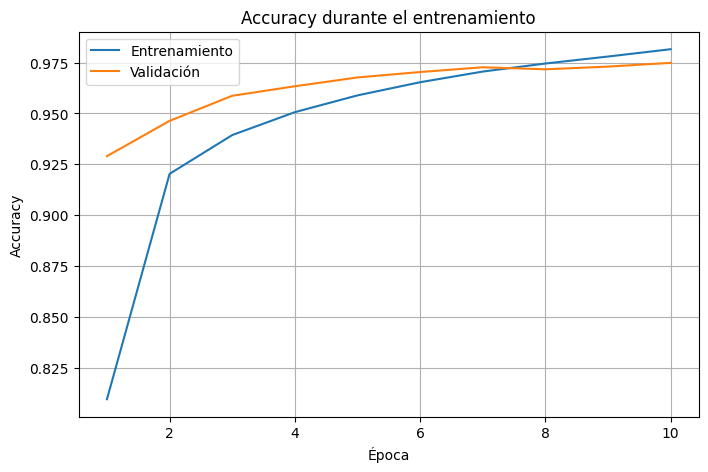

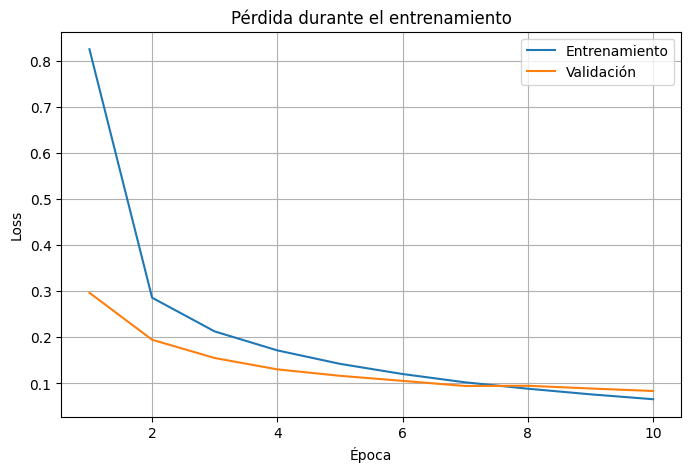

In [8]:
# Extracción de las métricas registradas durante las épocas de entrenamiento.
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

# Curva de accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracy, label="Entrenamiento")
plt.plot(epochs, val_accuracy, label="Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Entrenamiento")
plt.plot(epochs, val_loss, label="Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Pérdida durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 13.8 MB/s eta 0:00:00


In [10]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.0/274.0 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

In [11]:
import optuna
import mlflow
import dagshub


def objective(trial):

    # Limpieza de la sesión de Keras.
    tf.keras.backend.clear_session()

    # Optuna selecciona el número de capas ocultas.
    n_layers = trial.suggest_int("n_layers", 1, 4)

    # Optuna selecciona la función de activación.
    activation = trial.suggest_categorical(
        "activation",
        ["relu", "tanh", "sigmoid"]
    )

    # Creación de la red secuencial.
    model = keras.Sequential()

    # Flatten
    model.add(keras.Input(shape=(28, 28)))
    model.add(keras.layers.Flatten())

    # Guardado de las neuronas de cada capa para registrarlas después.
    units_per_layer = []

    # Construcción de las capas ocultas.
    for i in range(n_layers):

        # Optuna selecciona el número de neuronas.
        units = trial.suggest_categorical(
            f"n_units_layer_{i+1}",
            [32, 64, 128, 256, 512]
        )

        units_per_layer.append(units)

        model.add(
            keras.layers.Dense(
                units=units,
                activation=activation
            )
        )

    # Capa de salida para las 10 clases de MNIST.
    model.add(
        keras.layers.Dense(
            10,
            activation="softmax"
        )
    )

    # Optuna selecciona el optimizador.
    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["adam", "rmsprop", "sgd"]
    )

    # Optuna selecciona el learning rate.
    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    # Creación del optimizador seleccionado.
    if optimizer_name == "adam":

        optimizer = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "rmsprop":

        optimizer = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    else:

        optimizer = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    # Compilación el modelo.
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Registro de este trial como un experimento de MLflow.
    with mlflow.start_run(
        run_name=f"Optuna_trial_{trial.number}"
    ):

        # Registro de los hiperparámetros.
        mlflow.log_params({
            "trial": trial.number,
            "n_layers": n_layers,
            "activation": activation,
            "optimizer": optimizer_name,
            "learning_rate": learning_rate,
            "batch_size": 128,
            "epochs": 10,
            "units_per_layer": str(units_per_layer)
        })

        # Registro del número total de parámetros.
        mlflow.log_param(
            "total_parameters",
            model.count_params()
        )

        # Entrenamiento de la red.
        history = model.fit(
            x_train,
            y_train,
            epochs=10,
            batch_size=128,
            validation_split=0.1,
            verbose=0
        )

        # Métricas de entrenamiento.
        train_accuracy = history.history["accuracy"]
        val_accuracy = history.history["val_accuracy"]
        train_loss = history.history["loss"]
        val_loss = history.history["val_loss"]

        # Registro de las métricas de cada época.
        for epoch in range(len(train_accuracy)):

            mlflow.log_metrics({
                "train_accuracy": train_accuracy[epoch],
                "val_accuracy": val_accuracy[epoch],
                "train_loss": train_loss[epoch],
                "val_loss": val_loss[epoch]
            }, step=epoch + 1)

        # Se toma la mejor accuracy de validación alcanzada.
        best_val_accuracy = max(val_accuracy)

        # Se obtiene en qué época se alcanzó.
        best_epoch = np.argmax(val_accuracy) + 1

        mlflow.log_metric(
            "best_val_accuracy",
            best_val_accuracy
        )

        mlflow.log_metric(
            "best_epoch",
            best_epoch
        )

    # Optuna intentará maximizar esta métrica.
    return best_val_accuracy

In [13]:
study.optimize(
    objective,
    n_trials=20
)

[I 2026-09-14 18:10:28,328] A new study created in memory with name: no-name-e015ea15-13ff-43d7-91c4-b55c16958553
2026/09/14 18:10:31 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/14 18:10:31 INFO mlflow.store.db.utils: Updating database tables
[I 2026-09-14 18:11:19,568] Trial 0 finished with value: 0.9616666436195374 and parameters: {'n_layers': 1, 'activation': 'tanh', 'n_units_layer_1': 512, 'optimizer': 'rmsprop', 'learning_rate': 0.00011652052243451049}. Best is trial 0 with value: 0.9616666436195374.
[I 2026-09-14 18:12:21,668] Trial 1 finished with value: 0.9428333044052124 and parameters: {'n_layers': 3, 'activation': 'relu', 'n_units_layer_1': 512, 'n_units_layer_2': 256, 'n_units_layer_3': 512, 'optimizer': 'sgd', 'learning_rate': 0.00630120716767986}. Best is trial 0 with value: 0.9616666436195374.
[I 2026-09-14 18:13:01,244] Trial 2 finished with value: 0.9800000190734863 and parameters: {'n_layers': 4, 'activation': 'tanh', 'n_units_layer_

In [14]:
# Convertimos los resultados de Optuna en una tabla.
trials_df = study.trials_dataframe()

# Columnas principales.
trials_df = trials_df[
    [
        "number",
        "value",
        "params_n_layers",
        "params_n_units_layer_1",
        "params_n_units_layer_2",
        "params_n_units_layer_3",
        "params_n_units_layer_4",
        "params_activation",
        "params_optimizer",
        "params_learning_rate"
    ]
]

trials_df = trials_df.rename(columns={
    "number": "trial",
    "value": "best_val_accuracy",
    "params_n_layers": "n_layers",
    "params_n_units_layer_1": "units_layer_1",
    "params_n_units_layer_2": "units_layer_2",
    "params_n_units_layer_3": "units_layer_3",
    "params_n_units_layer_4": "units_layer_4",
    "params_activation": "activation",
    "params_optimizer": "optimizer",
    "params_learning_rate": "learning_rate"
})

# Orden de los experimentos de acuerdo con su accuracy de validación.
trials_df = trials_df.sort_values(
    "best_val_accuracy",
    ascending=False
).reset_index(drop=True)

trials_df

,trial,best_val_accuracy,n_layers,units_layer_1,units_layer_2,units_layer_3,units_layer_4,activation,optimizer,learning_rate
0,10,0.983167,1,256,NaN,NaN,NaN,tanh,rmsprop,0.003108
1,13,0.982000,2,256,128.0,NaN,NaN,tanh,rmsprop,0.001385
2,18,0.981667,2,256,128.0,NaN,NaN,tanh,rmsprop,0.001188
3,15,0.981500,1,256,NaN,NaN,NaN,tanh,rmsprop,0.000927
4,14,0.981333,1,256,NaN,NaN,NaN,tanh,rmsprop,0.004731
5,12,0.980000,3,256,128.0,64.0,NaN,relu,rmsprop,0.004889
6,2,0.980000,4,256,128.0,64.0,256.0,tanh,rmsprop,0.001590
7,11,0.979000,4,256,128.0,64.0,256.0,tanh,rmsprop,0.001182
8,16,0.978667,2,256,32.0,NaN,NaN,tanh,adam,0.000507
9,17,0.977833,2,64,512.0,NaN,NaN,tanh,rmsprop,0.002271


In [15]:
# Arquitectura seleccionada por Optuna en el Trial 12.
best_model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

# Uso del optimizador y learning rate seleccionados por Optuna.
best_optimizer = keras.optimizers.RMSprop(
    learning_rate=0.0014593339089122514
)
best_model.compile(
    optimizer=best_optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 453,962 (1.73 MB)

 Trainable params: 453,962 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Entrenamiento de la arquitectura del Trial 12
best_history = best_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9155 - loss: 0.2731 - val_accuracy: 0.9693 - val_loss: 0.1039
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9689 - loss: 0.1011 - val_accuracy: 0.9715 - val_loss: 0.1075
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9801 - loss: 0.0646 - val_accuracy: 0.9747 - val_loss: 0.0884
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9843 - loss: 0.0495 - val_accuracy: 0.9775 - val_loss: 0.0833
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9881 - loss: 0.0379 - val_accuracy: 0.9808 - val_loss: 0.0726
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.9728 - val_loss: 0.1255
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9923 - loss: 0.0262 - val_accuracy: 0.9723 - val_loss: 0.1392
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9931 - loss: 0.0216 - val_accu

In [17]:
# Evaluación.
best_test_loss, best_test_accuracy = best_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test loss: {best_test_loss:.4f}")
print(f"Test accuracy: {best_test_accuracy:.4f}")

Test loss: 0.1296
Test accuracy: 0.9779


In [18]:
# Busqueda del factor de regularización L1
def objective_l1(trial):

    l1_rate = trial.suggest_float(
        "l1_rate",
        1e-6,
        1e-2,
        log=True
    )

    # Modelo: misma arquitectura del Trial 12
    model = keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),

        keras.layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.L1(l1_rate)
        ),

        keras.layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=keras.regularizers.L1(l1_rate)
        ),

        keras.layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=keras.regularizers.L1(l1_rate)
        ),

        keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    # Mismo optimizador encontrado por Optuna en el inciso (a)
    optimizer = keras.optimizers.RMSprop(
        learning_rate=0.0014593339089122514
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # MLflow: cada trial de Optuna será un run independiente
    with mlflow.start_run(
        run_name=f"L1_Trial_{trial.number}",
        nested=True
    ):

        # Identificación del experimento
        mlflow.set_tag("tipo_experimento", "regularizacion")
        mlflow.set_tag("regularizador", "L1")
        mlflow.set_tag("optuna_trial", trial.number)

        # Parámetros
        mlflow.log_param("regularization", "L1")
        mlflow.log_param("l1_rate", l1_rate)
        mlflow.log_param("architecture", "512-64-256")
        mlflow.log_param("activation", "relu")
        mlflow.log_param("optimizer", "RMSprop")
        mlflow.log_param(
            "learning_rate",
            0.0014593339089122514
        )
        mlflow.log_param("epochs", 10)
        mlflow.log_param("batch_size", 128)

        # Entrenamiento
        history = model.fit(
            x_train,
            y_train,
            epochs=10,
            batch_size=128,
            validation_split=0.1,
            verbose=0
        )

        # Mejor resultado de validación
        best_val_accuracy = max(
            history.history["val_accuracy"]
        )

        best_val_loss = min(
            history.history["val_loss"]
        )

        # Registrar métricas finales del trial
        mlflow.log_metric(
            "best_val_accuracy",
            best_val_accuracy
        )

        mlflow.log_metric(
            "best_val_loss",
            best_val_loss
        )

        # Registrar las métricas de cada época
        for epoch in range(len(history.history["accuracy"])):

            mlflow.log_metric(
                "train_accuracy",
                history.history["accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_accuracy",
                history.history["val_accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "train_loss",
                history.history["loss"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_loss",
                history.history["val_loss"][epoch],
                step=epoch
            )

        # Permitir que Optuna vea también el valor
        trial.set_user_attr(
            "best_val_accuracy",
            best_val_accuracy
        )

    return best_val_accuracy

In [19]:
study_l1 = optuna.create_study(
    direction="maximize",
    study_name="MNIST_L1"
)

study_l1.optimize(
    objective_l1,
    n_trials=10
)

print("MEJOR RESULTADO L1")
print(f"Trial: {study_l1.best_trial.number}")
print(
    f"L1 rate: "
    f"{study_l1.best_params['l1_rate']:.8f}"
)
print(
    f"Best validation accuracy: "
    f"{study_l1.best_value:.4f}"
)

[I 2026-09-14 18:23:19,088] A new study created in memory with name: MNIST_L1
[I 2026-09-14 18:24:21,675] Trial 0 finished with value: 0.9298333525657654 and parameters: {'l1_rate': 0.0025766838001270807}. Best is trial 0 with value: 0.9298333525657654.
[I 2026-09-14 18:25:15,798] Trial 1 finished with value: 0.9828333258628845 and parameters: {'l1_rate': 3.046101426096915e-06}. Best is trial 1 with value: 0.9828333258628845.
[I 2026-09-14 18:26:12,658] Trial 2 finished with value: 0.9315000176429749 and parameters: {'l1_rate': 0.0027179140657803704}. Best is trial 1 with value: 0.9828333258628845.
[I 2026-09-14 18:27:04,915] Trial 3 finished with value: 0.9825000166893005 and parameters: {'l1_rate': 5.582450157358032e-05}. Best is trial 1 with value: 0.9828333258628845.
[I 2026-09-14 18:27:58,210] Trial 4 finished with value: 0.9821666479110718 and parameters: {'l1_rate': 7.964413002705275e-05}. Best is trial 1 with value: 0.9828333258628845.
[I 2026-09-14 18:28:54,942] Trial 5 finish

MEJOR RESULTADO L1
Trial: 5
L1 rate: 0.00002296
Best validation accuracy: 0.9833


In [20]:
# Busqueda del factor de regularización L2

def objective_l2(trial):

    l2_rate = trial.suggest_float(
        "l2_rate",
        1e-6,
        1e-2,
        log=True
    )

    # Misma arquitectura del Trial 12
    model = keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),

        keras.layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=keras.regularizers.L2(l2_rate)
        ),

        keras.layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=keras.regularizers.L2(l2_rate)
        ),

        keras.layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=keras.regularizers.L2(l2_rate)
        ),

        keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    # Mismo optimizador del modelo base
    optimizer = keras.optimizers.RMSprop(
        learning_rate=0.0014593339089122514
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Cada trial queda registrado en MLflow
    with mlflow.start_run(
        run_name=f"L2_Trial_{trial.number}",
        nested=True
    ):

        mlflow.set_tag("tipo_experimento", "regularizacion")
        mlflow.set_tag("regularizador", "L2")
        mlflow.set_tag("optuna_trial", trial.number)

        # Parámetros
        mlflow.log_param("regularization", "L2")
        mlflow.log_param("l2_rate", l2_rate)
        mlflow.log_param("architecture", "512-64-256")
        mlflow.log_param("activation", "relu")
        mlflow.log_param("optimizer", "RMSprop")
        mlflow.log_param(
            "learning_rate",
            0.0014593339089122514
        )
        mlflow.log_param("epochs", 10)
        mlflow.log_param("batch_size", 128)

        # Entrenamiento
        history = model.fit(
            x_train,
            y_train,
            epochs=10,
            batch_size=128,
            validation_split=0.1,
            verbose=0
        )

        # Mejores resultados
        best_val_accuracy = max(
            history.history["val_accuracy"]
        )

        best_val_loss = min(
            history.history["val_loss"]
        )

        # Registrar mejores métricas
        mlflow.log_metric(
            "best_val_accuracy",
            best_val_accuracy
        )

        mlflow.log_metric(
            "best_val_loss",
            best_val_loss
        )

        # Registrar curvas por época
        for epoch in range(len(history.history["accuracy"])):

            mlflow.log_metric(
                "train_accuracy",
                history.history["accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_accuracy",
                history.history["val_accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "train_loss",
                history.history["loss"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_loss",
                history.history["val_loss"][epoch],
                step=epoch
            )

        trial.set_user_attr(
            "best_val_accuracy",
            best_val_accuracy
        )

    return best_val_accuracy

In [21]:
study_l2 = optuna.create_study(
    direction="maximize",
    study_name="MNIST_L2"
)

study_l2.optimize(
    objective_l2,
    n_trials=10
)

print("MEJOR RESULTADO L2")
print(f"Trial: {study_l2.best_trial.number}")
print(
    f"L2 rate: "
    f"{study_l2.best_params['l2_rate']:.8f}"
)
print(
    f"Best validation accuracy: "
    f"{study_l2.best_value:.4f}"
)

[I 2026-09-14 18:33:09,440] A new study created in memory with name: MNIST_L2
[I 2026-09-14 18:34:16,305] Trial 0 finished with value: 0.9796666502952576 and parameters: {'l2_rate': 4.847933449856565e-05}. Best is trial 0 with value: 0.9796666502952576.
[I 2026-09-14 18:35:14,197] Trial 1 finished with value: 0.9745000004768372 and parameters: {'l2_rate': 0.003487045286120763}. Best is trial 0 with value: 0.9796666502952576.
[I 2026-09-14 18:36:19,394] Trial 2 finished with value: 0.9810000061988831 and parameters: {'l2_rate': 0.0005796394454096097}. Best is trial 2 with value: 0.9810000061988831.
[I 2026-09-14 18:37:24,001] Trial 3 finished with value: 0.9793333411216736 and parameters: {'l2_rate': 0.000164406946273777}. Best is trial 2 with value: 0.9810000061988831.
[I 2026-09-14 18:38:22,988] Trial 4 finished with value: 0.9825000166893005 and parameters: {'l2_rate': 3.353185602092918e-05}. Best is trial 4 with value: 0.9825000166893005.
[I 2026-09-14 18:39:17,549] Trial 5 finished

MEJOR RESULTADO L2
Trial: 9
L2 rate: 0.00000157
Best validation accuracy: 0.9828


In [22]:
# Regularizador combinado L1 + L2
def objective_l1_l2(trial):

    # Optuna busca ambos factores de regularización
    l1_rate = trial.suggest_float(
        "l1_rate",
        1e-6,
        1e-2,
        log=True
    )

    l2_rate = trial.suggest_float(
        "l2_rate",
        1e-6,
        1e-2,
        log=True
    )

    # Regularizador combinado L1 + L2
    regularizer = keras.regularizers.L1L2(
        l1=l1_rate,
        l2=l2_rate
    )

    # Misma arquitectura del Trial 12
    model = keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),

        keras.layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        keras.layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        keras.layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    # Mismo optimizador del modelo base
    optimizer = keras.optimizers.RMSprop(
        learning_rate=0.0014593339089122514
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Registrar trial en MLflow
    with mlflow.start_run(
        run_name=f"L1L2_Trial_{trial.number}",
        nested=True
    ):

        mlflow.set_tag(
            "tipo_experimento",
            "regularizacion"
        )

        mlflow.set_tag(
            "regularizador",
            "L1-L2"
        )

        mlflow.set_tag(
            "optuna_trial",
            trial.number
        )

        # Parámetros
        mlflow.log_param(
            "regularization",
            "L1-L2"
        )

        mlflow.log_param(
            "l1_rate",
            l1_rate
        )

        mlflow.log_param(
            "l2_rate",
            l2_rate
        )

        mlflow.log_param(
            "architecture",
            "512-64-256"
        )

        mlflow.log_param(
            "activation",
            "relu"
        )

        mlflow.log_param(
            "optimizer",
            "RMSprop"
        )

        mlflow.log_param(
            "learning_rate",
            0.0014593339089122514
        )

        mlflow.log_param(
            "epochs",
            10
        )

        mlflow.log_param(
            "batch_size",
            128
        )

        # Entrenamiento
        history = model.fit(
            x_train,
            y_train,
            epochs=10,
            batch_size=128,
            validation_split=0.1,
            verbose=0
        )

        # Mejores métricas
        best_val_accuracy = max(
            history.history["val_accuracy"]
        )

        best_val_loss = min(
            history.history["val_loss"]
        )

        # Registrar mejores métricas
        mlflow.log_metric(
            "best_val_accuracy",
            best_val_accuracy
        )

        mlflow.log_metric(
            "best_val_loss",
            best_val_loss
        )

        # Registrar curvas por época
        for epoch in range(
            len(history.history["accuracy"])
        ):

            mlflow.log_metric(
                "train_accuracy",
                history.history["accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_accuracy",
                history.history["val_accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "train_loss",
                history.history["loss"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_loss",
                history.history["val_loss"][epoch],
                step=epoch
            )

        trial.set_user_attr(
            "best_val_accuracy",
            best_val_accuracy
        )

    return best_val_accuracy

In [23]:
study_l1_l2 = optuna.create_study(
    direction="maximize",
    study_name="MNIST_L1_L2"
)

study_l1_l2.optimize(
    objective_l1_l2,
    n_trials=10
)

print("MEJOR RESULTADO L1-L2")

print(
    f"Trial: "
    f"{study_l1_l2.best_trial.number}"
)

print(
    f"L1 rate: "
    f"{study_l1_l2.best_params['l1_rate']:.8f}"
)

print(
    f"L2 rate: "
    f"{study_l1_l2.best_params['l2_rate']:.8f}"
)

print(
    f"Best validation accuracy: "
    f"{study_l1_l2.best_value:.4f}"
)

[I 2026-09-14 18:43:22,323] A new study created in memory with name: MNIST_L1_L2
[I 2026-09-14 18:44:18,608] Trial 0 finished with value: 0.9678333401679993 and parameters: {'l1_rate': 0.0008269322566700153, 'l2_rate': 4.822002567000653e-06}. Best is trial 0 with value: 0.9678333401679993.
[I 2026-09-14 18:45:16,436] Trial 1 finished with value: 0.9803333282470703 and parameters: {'l1_rate': 9.263064595099412e-05, 'l2_rate': 0.00022996116704166968}. Best is trial 1 with value: 0.9803333282470703.
[I 2026-09-14 18:46:13,991] Trial 2 finished with value: 0.9815000295639038 and parameters: {'l1_rate': 5.5786215087439095e-05, 'l2_rate': 3.156048212040262e-06}. Best is trial 2 with value: 0.9815000295639038.
[I 2026-09-14 18:47:17,288] Trial 3 finished with value: 0.9779999852180481 and parameters: {'l1_rate': 0.00017166293561941002, 'l2_rate': 0.00045628330896912544}. Best is trial 2 with value: 0.9815000295639038.
[I 2026-09-14 18:48:18,663] Trial 4 finished with value: 0.9738333225250244

MEJOR RESULTADO L1-L2
Trial: 2
L1 rate: 0.00005579
L2 rate: 0.00000316
Best validation accuracy: 0.9815


In [24]:
# Para Dropout
def objective_dropout(trial):

    # Optuna busca el porcentaje de dropout
    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    # Misma arquitectura del Trial 12,
    # agregando Dropout después de cada capa oculta
    model = keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),

        keras.layers.Dense(
            512,
            activation="relu"
        ),

        keras.layers.Dropout(
            dropout_rate
        ),

        keras.layers.Dense(
            64,
            activation="relu"
        ),

        keras.layers.Dropout(
            dropout_rate
        ),

        keras.layers.Dense(
            256,
            activation="relu"
        ),

        keras.layers.Dropout(
            dropout_rate
        ),

        keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    # Mismo optimizador del modelo base
    optimizer = keras.optimizers.RMSprop(
        learning_rate=0.0014593339089122514
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Registrar trial en MLflow
    with mlflow.start_run(
        run_name=f"Dropout_Trial_{trial.number}",
        nested=True
    ):

        mlflow.set_tag(
            "tipo_experimento",
            "regularizacion"
        )

        mlflow.set_tag(
            "regularizador",
            "Dropout"
        )

        mlflow.set_tag(
            "optuna_trial",
            trial.number
        )

        # Parámetros
        mlflow.log_param(
            "regularization",
            "Dropout"
        )

        mlflow.log_param(
            "dropout_rate",
            dropout_rate
        )

        mlflow.log_param(
            "architecture",
            "512-64-256"
        )

        mlflow.log_param(
            "activation",
            "relu"
        )

        mlflow.log_param(
            "optimizer",
            "RMSprop"
        )

        mlflow.log_param(
            "learning_rate",
            0.0014593339089122514
        )

        mlflow.log_param(
            "epochs",
            10
        )

        mlflow.log_param(
            "batch_size",
            128
        )

        # Entrenamiento
        history = model.fit(
            x_train,
            y_train,
            epochs=10,
            batch_size=128,
            validation_split=0.1,
            verbose=0
        )

        # Mejores métricas
        best_val_accuracy = max(
            history.history["val_accuracy"]
        )

        best_val_loss = min(
            history.history["val_loss"]
        )

        # Registrar mejores métricas
        mlflow.log_metric(
            "best_val_accuracy",
            best_val_accuracy
        )

        mlflow.log_metric(
            "best_val_loss",
            best_val_loss
        )

        # Registrar curvas
        for epoch in range(
            len(history.history["accuracy"])
        ):

            mlflow.log_metric(
                "train_accuracy",
                history.history["accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_accuracy",
                history.history["val_accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "train_loss",
                history.history["loss"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_loss",
                history.history["val_loss"][epoch],
                step=epoch
            )

        trial.set_user_attr(
            "best_val_accuracy",
            best_val_accuracy
        )

    return best_val_accuracy

In [25]:
study_dropout = optuna.create_study(
    direction="maximize",
    study_name="MNIST_Dropout"
)

study_dropout.optimize(
    objective_dropout,
    n_trials=10
)

print("MEJOR RESULTADO DROPOUT")

print(
    f"Trial: "
    f"{study_dropout.best_trial.number}"
)

print(
    f"Dropout rate: "
    f"{study_dropout.best_params['dropout_rate']:.4f}"
)

print(
    f"Best validation accuracy: "
    f"{study_dropout.best_value:.4f}"
)

[I 2026-09-14 18:53:45,125] A new study created in memory with name: MNIST_Dropout
[I 2026-09-14 18:54:48,165] Trial 0 finished with value: 0.9833333492279053 and parameters: {'dropout_rate': 0.19610432938502656}. Best is trial 0 with value: 0.9833333492279053.
[I 2026-09-14 18:55:55,005] Trial 1 finished with value: 0.9828333258628845 and parameters: {'dropout_rate': 0.3554863249917787}. Best is trial 0 with value: 0.9833333492279053.
[I 2026-09-14 18:57:01,423] Trial 2 finished with value: 0.9818333387374878 and parameters: {'dropout_rate': 0.4965504425302446}. Best is trial 0 with value: 0.9833333492279053.
[I 2026-09-14 18:58:04,121] Trial 3 finished with value: 0.9829999804496765 and parameters: {'dropout_rate': 0.43408097971276594}. Best is trial 0 with value: 0.9833333492279053.
[I 2026-09-14 18:59:05,873] Trial 4 finished with value: 0.9831666946411133 and parameters: {'dropout_rate': 0.3595395574714496}. Best is trial 0 with value: 0.9833333492279053.
[I 2026-09-14 19:00:02,33

MEJOR RESULTADO DROPOUT
Trial: 7
Dropout rate: 0.3252
Best validation accuracy: 0.9837


In [26]:
# Dropout + L1-L2
def objective_dropout_l1_l2(trial):

    # Optuna busca los tres hiperparámetros
    l1_rate = trial.suggest_float(
        "l1_rate",
        1e-6,
        1e-2,
        log=True
    )

    l2_rate = trial.suggest_float(
        "l2_rate",
        1e-6,
        1e-2,
        log=True
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    # Regularizador combinado L1 + L2
    regularizer = keras.regularizers.L1L2(
        l1=l1_rate,
        l2=l2_rate
    )

    # Misma arquitectura del Trial 12
    # + L1/L2 + Dropout
    model = keras.Sequential([
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),

        keras.layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        keras.layers.Dropout(
            dropout_rate
        ),

        keras.layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        keras.layers.Dropout(
            dropout_rate
        ),

        keras.layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        keras.layers.Dropout(
            dropout_rate
        ),

        keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    # Mismo optimizador encontrado en el inciso (a)
    optimizer = keras.optimizers.RMSprop(
        learning_rate=0.0014593339089122514
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Registrar el trial en MLflow
    with mlflow.start_run(
        run_name=f"Dropout_L1L2_Trial_{trial.number}",
        nested=True
    ):

        # Identificación
        mlflow.set_tag(
            "tipo_experimento",
            "regularizacion"
        )

        mlflow.set_tag(
            "regularizador",
            "Dropout + L1-L2"
        )

        mlflow.set_tag(
            "optuna_trial",
            trial.number
        )

        # Parámetros
        mlflow.log_param(
            "regularization",
            "Dropout + L1-L2"
        )

        mlflow.log_param(
            "l1_rate",
            l1_rate
        )

        mlflow.log_param(
            "l2_rate",
            l2_rate
        )

        mlflow.log_param(
            "dropout_rate",
            dropout_rate
        )

        mlflow.log_param(
            "architecture",
            "512-64-256"
        )

        mlflow.log_param(
            "activation",
            "relu"
        )

        mlflow.log_param(
            "optimizer",
            "RMSprop"
        )

        mlflow.log_param(
            "learning_rate",
            0.0014593339089122514
        )

        mlflow.log_param(
            "epochs",
            10
        )

        mlflow.log_param(
            "batch_size",
            128
        )

        # Entrenamiento
        history = model.fit(
            x_train,
            y_train,
            epochs=10,
            batch_size=128,
            validation_split=0.1,
            verbose=0
        )

        # Mejores métricas
        best_val_accuracy = max(
            history.history["val_accuracy"]
        )

        best_val_loss = min(
            history.history["val_loss"]
        )

        # Registrar mejores resultados
        mlflow.log_metric(
            "best_val_accuracy",
            best_val_accuracy
        )

        mlflow.log_metric(
            "best_val_loss",
            best_val_loss
        )

        # Registrar curvas de entrenamiento
        for epoch in range(
            len(history.history["accuracy"])
        ):

            mlflow.log_metric(
                "train_accuracy",
                history.history["accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_accuracy",
                history.history["val_accuracy"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "train_loss",
                history.history["loss"][epoch],
                step=epoch
            )

            mlflow.log_metric(
                "val_loss",
                history.history["val_loss"][epoch],
                step=epoch
            )

        trial.set_user_attr(
            "best_val_accuracy",
            best_val_accuracy
        )

    return best_val_accuracy

In [27]:
study_dropout_l1_l2 = optuna.create_study(
    direction="maximize",
    study_name="MNIST_Dropout_L1_L2"
)

study_dropout_l1_l2.optimize(
    objective_dropout_l1_l2,
    n_trials=10
)

print("MEJOR RESULTADO DROPOUT + L1-L2")

print(
    f"Trial: "
    f"{study_dropout_l1_l2.best_trial.number}"
)

print(
    f"L1 rate: "
    f"{study_dropout_l1_l2.best_params['l1_rate']:.8f}"
)

print(
    f"L2 rate: "
    f"{study_dropout_l1_l2.best_params['l2_rate']:.8f}"
)

print(
    f"Dropout rate: "
    f"{study_dropout_l1_l2.best_params['dropout_rate']:.4f}"
)

print(
    f"Best validation accuracy: "
    f"{study_dropout_l1_l2.best_value:.4f}"
)

[I 2026-09-14 19:04:11,809] A new study created in memory with name: MNIST_Dropout_L1_L2
[I 2026-09-14 19:05:22,292] Trial 0 finished with value: 0.10499999672174454 and parameters: {'l1_rate': 0.005716148494079894, 'l2_rate': 1.3063685615687408e-06, 'dropout_rate': 0.12057571138159312}. Best is trial 0 with value: 0.10499999672174454.
[I 2026-09-14 19:06:35,993] Trial 1 finished with value: 0.9626666903495789 and parameters: {'l1_rate': 0.0007603339233421418, 'l2_rate': 6.771373014535919e-05, 'dropout_rate': 0.3336130626419767}. Best is trial 1 with value: 0.9626666903495789.
[I 2026-09-14 19:07:57,616] Trial 2 finished with value: 0.10499999672174454 and parameters: {'l1_rate': 0.005402022756488472, 'l2_rate': 0.0037396227774463974, 'dropout_rate': 0.489010437341057}. Best is trial 1 with value: 0.9626666903495789.
[I 2026-09-14 19:09:11,345] Trial 3 finished with value: 0.971666693687439 and parameters: {'l1_rate': 0.00030718817778619057, 'l2_rate': 4.104206660245212e-05, 'dropout_r

MEJOR RESULTADO DROPOUT + L1-L2
Trial: 4
L1 rate: 0.00000215
L2 rate: 0.00002751
Dropout rate: 0.2378
Best validation accuracy: 0.9823
